# 01 Geology Features + Hyperbolic Decline — Hazeem's Track

**Task:** engineer features from the 3D grid files (03–08), plug them into standard regressors (Ridge, SVR) and pair them with hyperbolic decline.

**Headline result (backtests scored with Anas's `backtest_engine.py`):**

| Model | Mean NRMSE | Worst experiment |
|---|---|---|
| Baseline (Anas, history-fit exponential) | 0.153 | 0.301 |
| **SVR + grid-normalised state → hyperbolic decline** | **0.083** | **0.142** |

**How to run:** set `DATA` below to the folder holding `uncertainty_params.parquet`, `production_timeseries.parquet` and the `grid_properties` folder (made by `00_prepare_data.py`). Runs in about 2 minutes on a laptop.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

HERE = Path.cwd()                                   # folder with this notebook + .py modules
import os
DATA = Path(os.environ.get("DWC_DATA", "~/Downloads/dwc26/data")).expanduser()  # <- change if needed
OUT = HERE / "outputs"; (OUT / "figures").mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(HERE))

import geo_features as gf, hz_model as hm, hz_plots as hp
import temporal_utils as tu                    # Anas's shared utilities (unchanged copy)
from backtest_engine import BacktestEngine      # Anas's referee (unchanged copy)
print("DATA:", DATA, "| exists:", DATA.exists())

DATA: /mnt/user-data/outputs/dwc_data | exists: True


In [2]:
gp = DATA / "grid_properties"                                  # folder of 10 parts ...
grid = pd.read_parquet(gp if gp.exists() else DATA / "grid_properties.parquet")  # ... or one file
unc = pd.read_parquet(DATA / "uncertainty_params.parquet")
_, curves = tu.load_shared(DATA)                               # cases 0-85 only (test labels untouched)
print("grid:", grid.shape, "| cases:", grid.case_num.nunique())

Production rows: 5725536
Excluded invalid date/value rows: 5637420


grid: (4251200, 25) | cases: 100


## Step 1 — Decode what each uncertainty parameter does to the grid

For every cell, regress `log(value_case / value_case1)` on the log of the 4 parameters. The slope shows which parameter moves that cell.

In [3]:
g = grid.sort_values(["case_num", "K Index", "J Index", "I Index"]).reset_index(drop=True)
n = g.case_num.value_counts().iloc[0]
cube = lambda col: g[col].to_numpy().reshape(-1, n)
u = unc.set_index("case_num").loc[sorted(g.case_num.unique()), gf.PARAMS]
P = np.log(u.to_numpy()); X = np.column_stack([np.ones(len(P)), P - P[0]])
rows = []
for short, col in [("PORO", "Porosity (PORO)"), ("PORV", "Pore Volume (PORV)"),
                   ("PERMX", "Permeability I (PERMX)"), ("PERMZ", "Permeability K (PERMZ)"),
                   ("TRANX", "Transmissibility I (TRANX)"), ("TRANY", "Transmissibility J (TRANY)"),
                   ("TRANZ", "Transmissibility K (TRANZ)"), ("SOIL", "Oil Saturation (SOIL)"),
                   ("PRESSURE", "Pressure (PRESSURE)")]:
    A = cube(col); pos = (A > 0).all(0)
    L = np.log(A[:, pos] / A[0, pos]); ch = ~np.all(np.abs(L) < 1e-6, 0)
    if ch.sum() == 0:
        rows.append({"property": short, "cells_changing": 0}); continue
    beta = np.linalg.lstsq(X, L[:, ch], rcond=None)[0][1:].T.round(2)
    for combo, cnt in pd.Series([tuple(b) for b in beta]).value_counts().head(2).items():
        rows.append({"property": short, "cells_changing": int(ch.sum()),
                     **dict(zip(["fault", "poro", "perm", "aquifer"], combo)), "cells_with_this_pattern": cnt})
pd.DataFrame(rows)

,property,cells_changing,fault,poro,perm,aquifer,cells_with_this_pattern
0,PORO,42512,-0.0,1.0,0.00,-0.0,42512.0
1,PORV,42512,0.0,1.0,0.00,-0.0,40226.0
2,PORV,42512,-0.0,1.0,0.00,1.0,2286.0
3,PERMX,11575,-0.0,0.0,1.00,-0.0,11575.0
4,PERMZ,0,NaN,NaN,NaN,NaN,NaN
5,TRANX,11069,-0.0,0.0,1.00,0.0,10600.0
6,TRANX,11069,0.0,-0.0,0.99,-0.0,435.0
7,TRANY,11158,-0.0,0.0,1.00,-0.0,11031.0
8,TRANY,11158,0.0,-0.0,0.99,-0.0,95.0
9,TRANZ,0,NaN,NaN,NaN,NaN,NaN


**What the grid reveals** (exponent 1.0 = the property scales exactly with that parameter):

- **Porosity multiplier** scales PORO and PORV in every cell.
- **Permeability multiplier** scales PERMX/TRANX/TRANY only in the **tight facies** (~0.5 mD cells in layers K13–31, about 19% of the oil). Good rock (~100 mD), Zone 1 (K1–5) and PERMZ/TRANZ never change.
- **Aquifer pore volume** scales PORV of the 2,286 aquifer cells at the east edge (I = 51–53), which hold about 84% of all pore volume.
- **Fault transmissibility** appears in **no** exported column. The simulator applies it to the fault faces separately, which is why grid summaries never correlated with it.
- SOIL, SWAT and PRESSURE are identical in all cases (initial state).

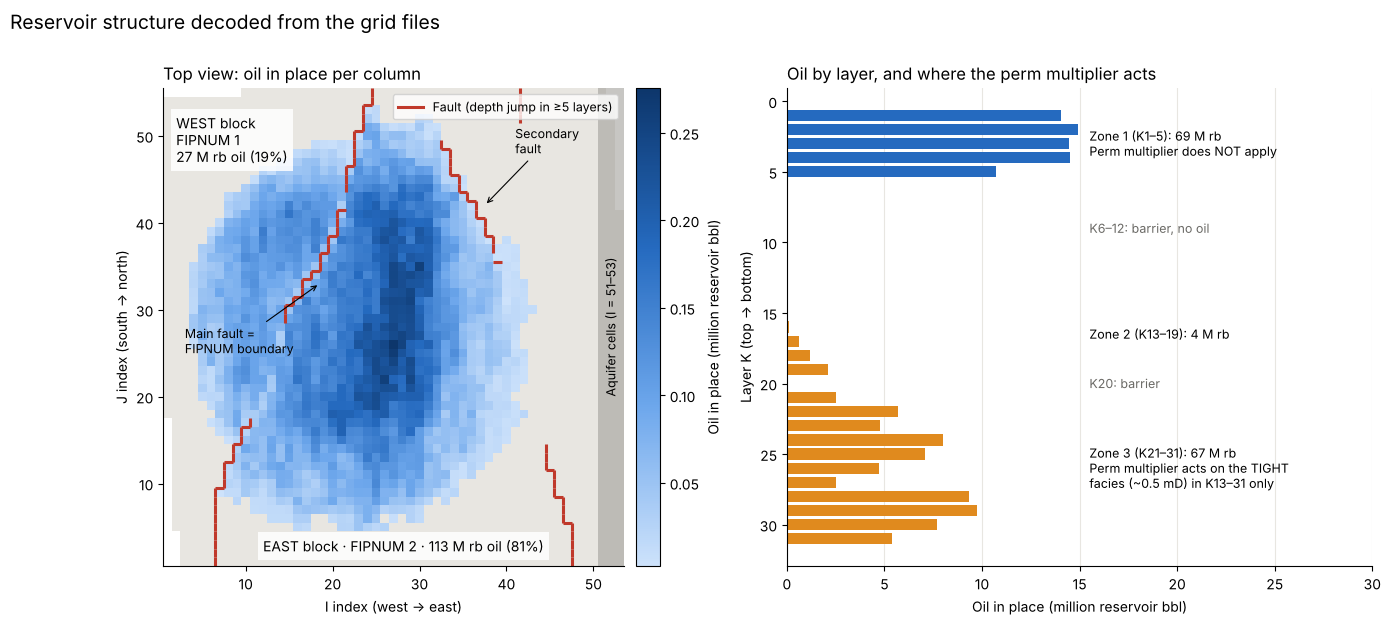

In [4]:
c1 = grid[grid.case_num == grid.case_num.min()]
fig = hp.plot_structure(c1, OUT / "figures" / "01_reservoir_structure.png")

The main fault (depth jumps between neighbouring columns) coincides with the FIPNUM 1/2 boundary, splitting the field into a **west block (19% of oil)** and an **east block (81%)**, with the aquifer attached to the east. The layers form three oil zones separated by barriers (K6–12, K20).

## Step 2 — Engineer physics features per case

`geo_features.build_features` computes, for every case and from that case's grid only:

- volumes: total, per-zone, west/east and tight-facies oil in place; aquifer pore volume
- flow capacity: per-zone and tight-facies transmissibility
- **cross-fault transmissibility** = FIPNUM-boundary transmissibility × the fault parameter
- ratios: aquifer-to-oil, tight drainage time, west-block connectivity, diffusivity

In [5]:
geo = gf.build_features(grid, unc)
geo.to_parquet(OUT / "geo_features.parquet")
geo[["OOIP_total", "OOIP_tight", "T_tight", "T_cross_fault", "PV_aquifer",
     "aquifer_to_oil_ratio", "tight_drainage_time"]].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
OOIP_total,1.486361e+08,2.641067e+07,1.036953e+08,1.933598e+08
OOIP_tight,2.767449e+07,4.917391e+06,1.930698e+07,3.600158e+07
T_tight,5.537488e+02,2.902151e+02,5.548347e+01,1.041504e+03
T_cross_fault,1.218374e+01,3.679658e+00,6.177211e+00,1.832646e+01
PV_aquifer,6.886422e+09,2.611832e+09,2.685337e+09,1.381613e+10
aquifer_to_oil_ratio,4.651900e+01,1.570418e+01,2.012418e+01,7.419488e+01
tight_drainage_time,8.514915e+04,9.645988e+04,2.197037e+04,6.283630e+05


## Step 3 — Ridge / SVR → hyperbolic decline, backtested

Arps hyperbolic decline: `dq/dt = −D·q` with `D = K·q^b`, so `ln D = ln K + b·ln q`. That is a linear model, which is exactly what Ridge fits.

- **Label:** realised oil decline over the next year, `D_fwd(c) = −ln(q(c+1y)/q(c))`, for every quarter c of every training case.
- **Features (state at c):** ln q, water cut, recent decline and water-cut trend, plus
  - *production state (no grid)*: raw cumulative oil and water
  - *grid-normalised state*: recovery factor = Np / grid OOIP, water index = Wp / grid aquifer PV
  - optional: raw 4 parameters or the 9 geology features
- **No time leakage:** only quarters whose 1-year label ends before the cutoff are used. Cases 1–70 are scored out-of-fold (5 folds, same seed as Anas) and 71–85 with a model trained on 1–70.
- **Decoder:** hyperbolic oil from the predicted D at the cutoff, `b` = within-case slope of ln D on ln q after each case's peak decline (clipped to [0, 1]). Gas = GOR × oil. Water uses Anas's history-fitted relaxation (stable; my learned water models were not).

In [6]:
panel = hm.build_panel(curves, range(1, 86), geo)
water = {}
for origin, h in hm.EXPERIMENTS:
    for c in range(1, 86):
        r = tu.target_from_history(tu.prefix_history(curves, c, origin)[0], "3y")
        water[(c, pd.Timestamp(origin))] = {"water_ratio": r["water_ratio"], "water_k": r["water_k"]}
print({o: hm.estimate_b(panel, range(1, 71), pd.Timestamp(o)) for o, _ in hm.EXPERIMENTS[1:]}, "<- Arps b per cutoff")

preds = []
for origin, h in hm.EXPERIMENTS:                       # baseline: Anas's history-fit 'Separate'
    dates = hm.experiment_dates(origin, h)
    for c in range(1, 86):
        rec = tu.target_from_history(tu.prefix_history(curves, c, origin)[0], "3y")
        cum, _ = tu.forecast(rec, "Separate", origin, dates)
        for j, ph in enumerate(tu.CUM_METRICS):
            preds.append(pd.DataFrame({"model_id": "Baseline_Anas_Separate_hist", "case_num": c,
                                       "origin": pd.Timestamp(origin), "horizon_years": h,
                                       "date": dates, "phase": ph, "prediction": cum[:, j]}))
configs = {"production state (no grid)": hm.STATE_NOGRID, "grid-normalised state": hm.STATE,
           "grid-normalised state + raw 4": hm.STATE + hm.RAW,
           "grid-normalised state + geology": hm.STATE + hm.GEO}
for name, cols in configs.items():
    for kind in ["Ridge", "SVR"]:
        preds.append(hm.run(panel, geo, cols, kind, f"{kind} | {name}", water_fits=water).drop(columns="b_used"))
P = pd.concat(preds, ignore_index=True)        # NB: the engine needs a unique row index
rep = BacktestEngine(curves).score_predictions(P)
assert not rep["validation_errors"], rep["validation_errors"]
ps = rep["phase_scores"]
pv = ps.pivot_table(index="model_id", columns=["origin", "horizon_years"], values="increment_NRMSE", aggfunc="mean")
pv.columns = [f"{o.year}-{h}y" for o, h in pv.columns]
pv["mean"] = pv.mean(1); pv["worst"] = pv.iloc[:, :4].max(1)
pv = pv.join(ps.groupby(["model_id", "phase"]).increment_NRMSE.mean().unstack()[["oil_cum", "water_cum"]])
pv = pv.join(ps[ps.split == "validation"].groupby("model_id").increment_NRMSE.mean().rename("validation_only"))
pv = pv.sort_values("mean"); pv.to_csv(OUT / "model_comparison.csv")
P.to_parquet(OUT / "backtest_predictions.parquet"); BacktestEngine(curves).export_report(rep, OUT / "referee")
pv.round(4)

{'2003-01-01': 0.0, '2004-01-01': 0.42579877913447306, '2005-01-01': 0.8179259572563564} <- Arps b per cutoff


Report exported to /home/claude/hz_pkg/outputs/referee


,2003-3y,2003-5y,2004-3y,2005-3y,mean,worst,oil_cum,water_cum,validation_only
model_id,,,,,,,,,
SVR | grid-normalised state,0.1060,0.1418,0.0403,0.0435,0.0829,0.1418,0.0493,0.1507,0.0798
Ridge | grid-normalised state,0.1298,0.1761,0.0594,0.0732,0.1096,0.1761,0.0891,0.1507,0.1122
SVR | grid-normalised state + raw 4,0.1449,0.1973,0.0486,0.0618,0.1131,0.1973,0.0946,0.1507,0.1094
SVR | production state (no grid),0.1435,0.2052,0.0601,0.0445,0.1133,0.2052,0.0949,0.1507,0.1075
Ridge | grid-normalised state + raw 4,0.1339,0.1791,0.0735,0.0745,0.1152,0.1791,0.0976,0.1507,0.1184
Ridge | grid-normalised state + geology,0.1341,0.1793,0.0734,0.0747,0.1154,0.1793,0.0978,0.1507,0.1185
SVR | grid-normalised state + geology,0.1507,0.2055,0.0579,0.0672,0.1203,0.2055,0.1054,0.1507,0.1171
Ridge | production state (no grid),0.1488,0.2081,0.0778,0.0471,0.1205,0.2081,0.1052,0.1507,0.1151
Baseline_Anas_Separate_hist,0.2099,0.3006,0.0563,0.0432,0.1525,0.3006,0.1533,0.1507,0.1538


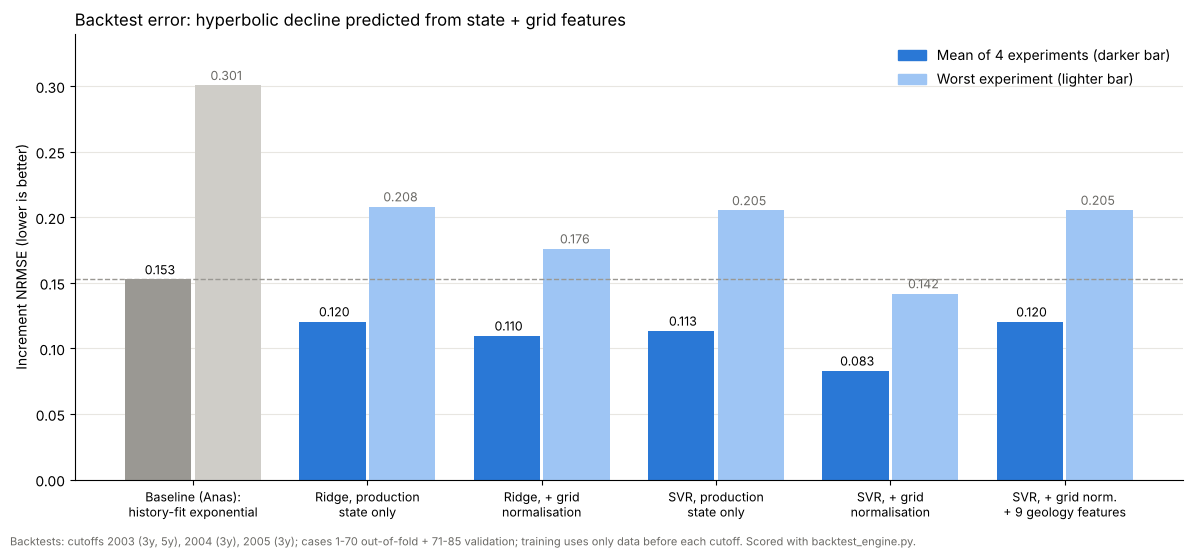

In [7]:
fig = hp.plot_backtest(pv, OUT / "figures" / "02_backtest_comparison.png")

**Reading the table**

- The learned decline beats the history-fit baseline everywhere except 2005-3y, where they tie, and it **halves the worst case** (2003-5y: 0.30 → 0.14).
- **Grid features matter through normalisation.** Turning cumulative production into a recovery factor (÷ grid OOIP) and a water index (÷ grid aquifer PV) cuts SVR error from 0.113 to 0.083.
- **Adding the raw 4 parameters or the 9 geology features on top makes it worse.** Before each cutoff there are few post-plateau rows, so extra inputs overfit.
- Validation-only scores track the overall scores, so it isn't overfitting the training cases.
- Water (≈0.15) is now the weakest phase.

## Step 4 — Deploy: 2008 → 2028

Train on cases 1–70 with every quarter up to 2008. Predict the decline at 2008 and keep it within 0.5–1.5× the observed 2007 decline. That guardrail costs nothing in the 2004/2005 backtests and catches 6 cases that sit outside the training range. Two decline shapes are exported:

- `b` from data (≈1, hyperbolic)
- `b = 0` (exponential, conservative)

In [8]:
cut = pd.Timestamp("2008-01-01"); dates = pd.date_range("2008-04-01", "2028-01-01", freq="QS")
tr = hm.train_rows(panel, range(1, 71), cut)
mD = hm.make_model("SVR").fit(hm.design(tr, geo, hm.STATE), tr.D_fwd.clip(lower=0))
b2008 = hm.estimate_b(panel, range(1, 71), cut)
st = panel[(panel.date == cut) & panel.case_num.between(1, 85)].copy()
raw = np.clip(mD.predict(hm.design(st, geo, hm.STATE)), 0, None)
st["D0"] = np.clip(raw, 0.5 * st.D_recent, 1.5 * st.D_recent)
print("Arps b at 2008:", b2008, "| guardrail adjusted cases:", st.loc[np.abs(raw - st.D0) > 1e-9, "case_num"].tolist())

rows = []
for _, s in st.iterrows():
    c = int(s.case_num); rec = tu.target_from_history(tu.prefix_history(curves, c, cut)[0], "3y")
    w = {"water_ratio": rec["water_ratio"], "water_k": rec["water_k"]}
    for bb, name in [(b2008, "Hazeem_SVR_hyperbolic"), (0.0, "Hazeem_SVR_exponential")]:
        cum = hm.hyperbolic_forecast(s, s.D0, bb, 0, dates, cut, water=w)
        for j, ph in enumerate(tu.CUM_METRICS):
            rows.append(pd.DataFrame({"model_id": name, "case_num": c, "origin": cut, "horizon_years": 20,
                                      "date": dates, "phase": ph, "prediction": cum[:, j]}))
    cum, _ = tu.forecast(rec, "Separate", cut, dates)
    for j, ph in enumerate(tu.CUM_METRICS):
        rows.append(pd.DataFrame({"model_id": "Baseline_Anas_Separate_hist", "case_num": c, "origin": cut,
                                  "horizon_years": 20, "date": dates, "phase": ph, "prediction": cum[:, j]}))
F = pd.concat(rows, ignore_index=True)
F.to_parquet(OUT / "forecast_2008_2028.parquet")

# also in DATA_CONTRACT.md format (one row per case x date)
wide = F[F.model_id.str.startswith("Hazeem")].pivot_table(index=["model_id", "case_num", "date"], columns="phase",
                                                         values="prediction").reset_index()
wide = wide.rename(columns={"case_num": "case_id", "date": "timestamp", "gas_cum": "pred_gas_cum_mscf",
                            "oil_cum": "pred_oil_cum_stb", "water_cum": "pred_water_cum_stb"})
wide["timestamp"] = wide.timestamp.dt.strftime("%Y-%m-%d"); wide["split_type"] = "forecast"
wide.to_parquet(OUT / "preds_Hazeem.parquet", index=False)

anchor = st.set_index("case_num")["no"]
end = F[(F.date == dates[-1]) & (F.phase == "oil_cum")].copy(); end["oil_2008_2028"] = end.prediction - end.case_num.map(anchor)
viol = int(F.sort_values("date").groupby(["model_id", "case_num", "phase"]).prediction.apply(lambda s: (s.diff() < -1e-6).sum()).sum())
print("decreasing cumulative steps:", viol)
(end.groupby("model_id").oil_2008_2028.agg(["median", "min", "max"]) / 1e6).round(2).rename_axis("20-yr extra oil, M STB")

Arps b at 2008: 1.0 | guardrail adjusted cases: [10, 12, 16, 59, 71, 73]


decreasing cumulative steps: 0


,median,min,max
"20-yr extra oil, M STB",,,
Baseline_Anas_Separate_hist,12.73,6.82,20.58
Hazeem_SVR_exponential,16.27,8.56,31.65
Hazeem_SVR_hyperbolic,20.94,11.67,33.70


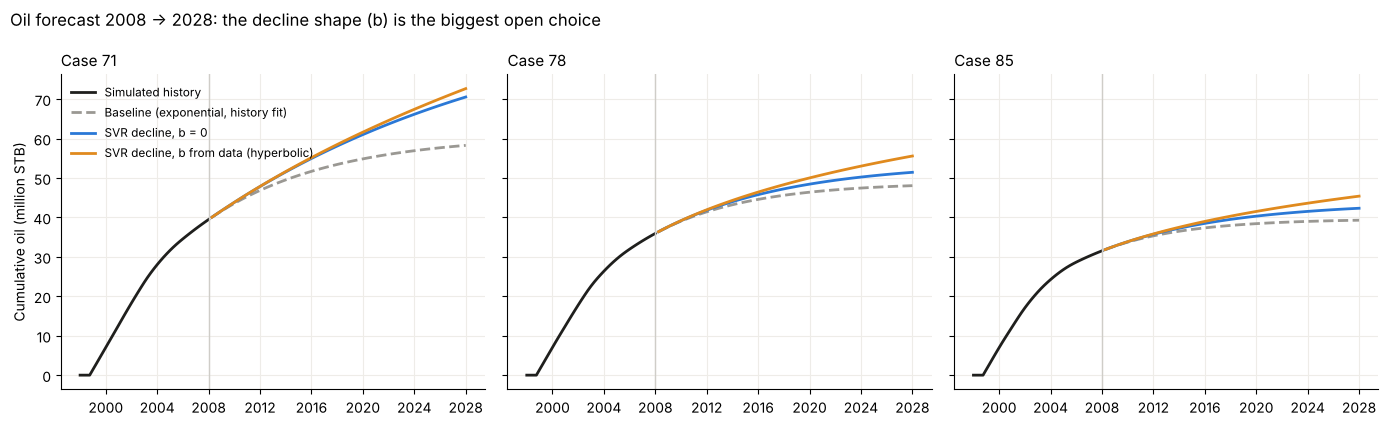

In [9]:
fig = hp.plot_forecast(F, panel, cases=(71, 78, 85), path=OUT / "figures" / "03_forecast_2028_examples.png")

## Conclusions and limitations

1. **The grid decodes cleanly.** Each multiplier acts on a specific region: porosity everywhere, permeability only on the tight facies in K13–31, aquifer volume on the east-edge cells. The fault parameter is not in the grid at all.
2. **Geology helps by normalising production state** (recovery factor, water index): about 25% lower error. Piling more geology or parameter inputs onto the regressor overfits.
3. **Ridge/SVR-predicted decline + hyperbolic decoder: 0.083 mean / 0.142 worst**, against the baseline's 0.153 / 0.301.
4. **Open choice for 2028:** `b` estimated from 2003–2007 is ≈1 (hyperbolic). That gives a median +20.9 M STB after 2008, versus +16.3 M STB with b = 0 and +12.7 M STB for the baseline. No backtest can confirm 20-year curvature, so the team should pick one or show both as a range.
5. **Water is now the weakest phase** (≈0.15). It is the next thing to improve.
6. The backtests only go to 5 years. They test the decline *level*, not the long-term *shape*. Test cases 86–100 are untouched.